# Performance Analytics — 40-Fund Scorecard

**⚠️ Running on synthetic placeholder data.** Real NAV / benchmark / expense-ratio
files haven't been supplied yet, so `nav_data.csv`, `benchmark_data.csv`, and
`expense_ratio.csv` sitting alongside this notebook were generated to match the
agreed schema — they are **not** real funds or real market history. Every scheme
is named/coded `Demo...` for that reason, and every number below (returns,
Sharpe, rankings, the scorecard, the chart) is illustrative only until real
data replaces these three files.

**To go live:** replace those three CSVs with real files using the same column
names and file names, then *Restart & Run All*. Nothing below needs to change.

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

## Configuration

In [2]:
NAV_FILE = 'nav_data.csv'
BENCHMARK_FILE = 'benchmark_data.csv'
EXPENSE_FILE = 'expense_ratio.csv'

RF_ANNUAL = 0.065                 # RBI repo-rate proxy, per spec
RF_DAILY = RF_ANNUAL / 252

LOOKBACK_YEARS = 3                # window for Sharpe / Sortino / Alpha-Beta / tracking error
TOP_N = 5                         # funds shown in the benchmark chart
TRADING_DAYS = 252
OUTLIER_THRESHOLD = 0.20          # flag daily moves bigger than this as likely data errors

## 1. Load & Validate

In [3]:
nav_long = pd.read_csv(NAV_FILE, parse_dates=['Date'])
nav_wide = nav_long.pivot(index='Date', columns='Scheme_Code', values='NAV').sort_index()
scheme_names = nav_long.drop_duplicates('Scheme_Code').set_index('Scheme_Code')['Scheme_Name']

bench = pd.read_csv(BENCHMARK_FILE, parse_dates=['Date']).set_index('Date').sort_index()
expense = pd.read_csv(EXPENSE_FILE).set_index('Scheme_Code')['Expense_Ratio']

asof = nav_wide.index.max()
print(f"Schemes: {nav_wide.shape[1]}")
print(f"NAV date range: {nav_wide.index.min().date()} -> {asof.date()}")
print(f"Benchmark date range: {bench.index.min().date()} -> {bench.index.max().date()}")
missing = nav_wide.isna().sum()
print(f"Schemes with any missing NAV rows: {(missing > 0).sum()}")

Schemes: 40
NAV date range: 2019-07-01 -> 2026-07-03
Benchmark date range: 2019-07-01 -> 2026-07-03
Schemes with any missing NAV rows: 0


## 2. Daily Returns — *(Task 1)*

`daily_return = nav_t / nav_t-1 - 1`, computed for all 40 schemes, then checked
for a sane distribution (summary stats, skew/kurtosis, an outlier flag for any
move bigger than ±20% in a single day, and a pooled histogram).

In [4]:
daily_returns = nav_wide.pct_change().iloc[1:]

dist_summary = daily_returns.describe().T[['mean', 'std', 'min', 'max']]
dist_summary['skew'] = daily_returns.skew()
dist_summary['kurtosis'] = daily_returns.kurtosis()
dist_summary = dist_summary.join(scheme_names).round(4)
dist_summary

,mean,std,min,max,skew,kurtosis,Scheme_Name
Scheme_Code,,,,,,,
DEMO01,0.0004,0.0096,-0.0563,0.0327,-0.4227,1.8676,Demo Fund 01 (Large Cap)
DEMO02,0.0005,0.0103,-0.0581,0.0339,-0.3695,1.6476,Demo Fund 02 (Large Cap)
DEMO03,0.0003,0.0111,-0.0650,0.0381,-0.3694,1.8456,Demo Fund 03 (Large Cap)
DEMO04,0.0004,0.0098,-0.0538,0.0352,-0.3790,1.7340,Demo Fund 04 (Large Cap)
DEMO05,0.0004,0.0093,-0.0523,0.0344,-0.3781,1.6545,Demo Fund 05 (Large Cap)
DEMO06,0.0006,0.0114,-0.0632,0.0361,-0.3746,1.6043,Demo Fund 06 (Large Cap)
DEMO07,0.0005,0.0111,-0.0627,0.0405,-0.4294,1.8515,Demo Fund 07 (Flexi Cap)
DEMO08,0.0003,0.0095,-0.0534,0.0303,-0.3436,1.3381,Demo Fund 08 (Flexi Cap)
DEMO09,0.0003,0.0097,-0.0590,0.0297,-0.4230,1.7696,Demo Fund 09 (Flexi Cap)


Schemes with |daily return| > 20% on any day (possible data errors):
None — distribution looks clean.


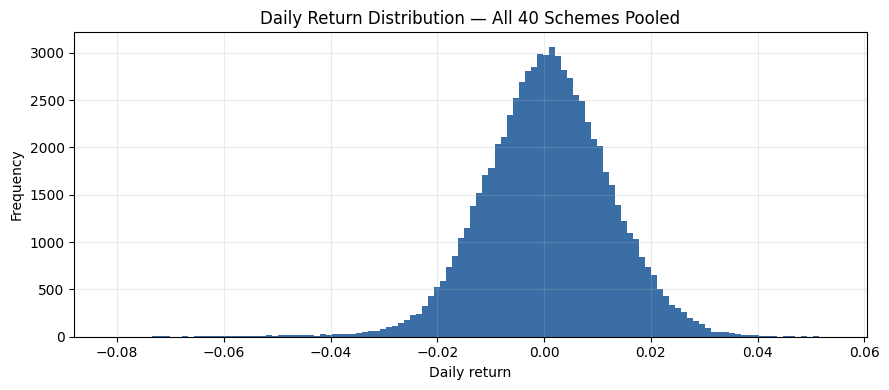

In [5]:
outlier_days = (daily_returns.abs() > OUTLIER_THRESHOLD).sum()
outlier_days = outlier_days[outlier_days > 0]
print(f"Schemes with |daily return| > {OUTLIER_THRESHOLD:.0%} on any day (possible data errors):")
print(outlier_days if len(outlier_days) else "None — distribution looks clean.")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(daily_returns.values.flatten(), bins=120, color='#3b6ea5', edgecolor='none')
ax.set_title('Daily Return Distribution — All 40 Schemes Pooled')
ax.set_xlabel('Daily return')
ax.set_ylabel('Frequency')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('return_distribution.png', dpi=150)
plt.show()

## 3. CAGR — 1Y / 3Y / 5Y — *(Task 2)*

`CAGR = (NAV_end / NAV_start) ^ (1/n) - 1`. Start dates are the closest
available trading day on/after (as-of date − n years). A scheme younger than
the window gets `NaN` for that column instead of a misleading number.

In [6]:
def cagr(series, years, asof_date):
    s = series.dropna()
    start_date = asof_date - pd.DateOffset(years=years)
    if len(s) == 0 or start_date < s.index.min():
        return np.nan
    idx = s.index.searchsorted(start_date)
    if idx >= len(s):
        return np.nan
    start_nav, end_nav = s.iloc[idx], s.loc[asof_date]
    if pd.isna(start_nav) or pd.isna(end_nav) or start_nav <= 0:
        return np.nan
    return (end_nav / start_nav) ** (1 / years) - 1

cagr_table = pd.DataFrame({
    '1Y_CAGR': {c: cagr(nav_wide[c], 1, asof) for c in nav_wide.columns},
    '3Y_CAGR': {c: cagr(nav_wide[c], 3, asof) for c in nav_wide.columns},
    '5Y_CAGR': {c: cagr(nav_wide[c], 5, asof) for c in nav_wide.columns},
})
cagr_table = cagr_table.join(scheme_names).sort_values('3Y_CAGR', ascending=False)
cagr_table.round(4)

,1Y_CAGR,3Y_CAGR,5Y_CAGR,Scheme_Name
DEMO19,0.0089,0.5189,0.4700,Demo Fund 19 (Small Cap)
DEMO21,0.4050,0.4693,0.4918,Demo Fund 21 (Small Cap)
DEMO20,0.2944,0.4542,0.4307,Demo Fund 20 (Small Cap)
DEMO14,0.2739,0.4061,0.4020,Demo Fund 14 (Mid Cap)
DEMO31,0.3014,0.3771,0.3453,Demo Fund 31 (Value)
DEMO30,0.2565,0.3741,0.3350,Demo Fund 30 (Value)
DEMO37,0.2183,0.3572,0.3266,Demo Fund 37 (Contra)
DEMO06,0.1719,0.3455,0.3250,Demo Fund 06 (Large Cap)
DEMO26,0.1912,0.3429,0.3606,Demo Fund 26 (ELSS)
DEMO32,0.2610,0.3407,0.3420,Demo Fund 32 (Value)


## 4. Sharpe Ratio — *(Task 3)*

`(Rp − Rf) / Std(Rp) × √252`, computed over the trailing 3-year window
(`LOOKBACK_YEARS` in Configuration above), Rf = 6.5%/252 daily. Ranked across
all 40 funds.

In [7]:
window_start = asof - pd.DateOffset(years=LOOKBACK_YEARS)
returns_window = daily_returns.loc[daily_returns.index >= window_start]

def sharpe(col):
    r = col.dropna()
    if len(r) < 60 or r.std() == 0:
        return np.nan
    return (r.mean() - RF_DAILY) / r.std() * np.sqrt(TRADING_DAYS)

sharpe_ratio = returns_window.apply(sharpe).rename('Sharpe')
sharpe_table = sharpe_ratio.to_frame().join(scheme_names).sort_values('Sharpe', ascending=False)
sharpe_table.insert(0, 'Rank', range(1, len(sharpe_table) + 1))
sharpe_table.round(4)

,Rank,Sharpe,Scheme_Name
Scheme_Code,,,
DEMO21,1,1.6414,Demo Fund 21 (Small Cap)
DEMO30,2,1.6181,Demo Fund 30 (Value)
DEMO37,3,1.5746,Demo Fund 37 (Contra)
DEMO20,4,1.5496,Demo Fund 20 (Small Cap)
DEMO19,5,1.5107,Demo Fund 19 (Small Cap)
DEMO31,6,1.4707,Demo Fund 31 (Value)
DEMO24,7,1.3951,Demo Fund 24 (ELSS)
DEMO06,8,1.3744,Demo Fund 06 (Large Cap)
DEMO14,9,1.3134,Demo Fund 14 (Mid Cap)


## 5. Sortino Ratio — *(Task 4)*

Same formula, but the denominator is the standard deviation of negative-return
days only.

In [8]:
def sortino(col):
    r = col.dropna()
    if len(r) < 60:
        return np.nan
    downside = r[r < 0]
    dd_std = downside.std()
    if not dd_std or pd.isna(dd_std):
        return np.nan
    return (r.mean() - RF_DAILY) / dd_std * np.sqrt(TRADING_DAYS)

sortino_ratio = returns_window.apply(sortino).rename('Sortino')
sortino_table = sortino_ratio.to_frame().join(scheme_names).sort_values('Sortino', ascending=False)
sortino_table.insert(0, 'Rank', range(1, len(sortino_table) + 1))
sortino_table.round(4)

,Rank,Sortino,Scheme_Name
Scheme_Code,,,
DEMO30,1,2.7951,Demo Fund 30 (Value)
DEMO21,2,2.7599,Demo Fund 21 (Small Cap)
DEMO37,3,2.7201,Demo Fund 37 (Contra)
DEMO20,4,2.6485,Demo Fund 20 (Small Cap)
DEMO19,5,2.4550,Demo Fund 19 (Small Cap)
DEMO31,6,2.4391,Demo Fund 31 (Value)
DEMO24,7,2.4326,Demo Fund 24 (ELSS)
DEMO06,8,2.3119,Demo Fund 06 (Large Cap)
DEMO11,9,2.2729,Demo Fund 11 (Flexi Cap)


## 6. Alpha & Beta vs Nifty 100 — *(Task 5)*

OLS of each fund's daily returns on Nifty 100 daily returns via
`scipy.stats.linregress`, over the same trailing 3-year window.
`Alpha = intercept × 252`, `Beta = slope`. R² and p-value come free from the
regression and are included as diagnostics.

In [9]:
bench_returns = bench.pct_change().dropna()
bench_returns_window = bench_returns.loc[bench_returns.index >= window_start]

ab_records = []
for code in returns_window.columns:
    y = returns_window[code].dropna()
    common = y.index.intersection(bench_returns_window.index)
    y_, x_ = y.loc[common], bench_returns_window.loc[common, 'Nifty100']
    if len(common) < 60:
        ab_records.append({'Scheme_Code': code, 'Beta': np.nan, 'Alpha': np.nan,
                            'R_squared': np.nan, 'p_value': np.nan, 'n_obs': len(common)})
        continue
    res = stats.linregress(x_, y_)
    ab_records.append({'Scheme_Code': code, 'Beta': res.slope, 'Alpha': res.intercept * TRADING_DAYS,
                        'R_squared': res.rvalue ** 2, 'p_value': res.pvalue, 'n_obs': len(common)})

alpha_beta_df = pd.DataFrame(ab_records).set_index('Scheme_Code').join(scheme_names)
alpha_beta_df = alpha_beta_df.sort_values('Alpha', ascending=False)

alpha_beta_out = alpha_beta_df.round(4)
alpha_beta_out.to_csv('alpha_beta.csv')
alpha_beta_out

,Beta,Alpha,R_squared,p_value,n_obs,Scheme_Name
Scheme_Code,,,,,,
DEMO21,1.0655,0.1114,0.7738,0.0,785,Demo Fund 21 (Small Cap)
DEMO19,1.2198,0.1096,0.6855,0.0,785,Demo Fund 19 (Small Cap)
DEMO37,0.8221,0.0896,0.7784,0.0,785,Demo Fund 37 (Contra)
DEMO30,0.8933,0.0816,0.8879,0.0,785,Demo Fund 30 (Value)
DEMO20,1.1620,0.0769,0.8643,0.0,785,Demo Fund 20 (Small Cap)
DEMO31,0.9774,0.0647,0.8407,0.0,785,Demo Fund 31 (Value)
DEMO14,1.0978,0.0639,0.6742,0.0,785,Demo Fund 14 (Mid Cap)
DEMO24,0.9209,0.0403,0.9314,0.0,785,Demo Fund 24 (ELSS)
DEMO06,1.0058,0.0362,0.9184,0.0,785,Demo Fund 06 (Large Cap)


## 7. Maximum Drawdown — *(Task 6)*

`min(NAV / running_max − 1)` over full history, plus the peak/trough dates
that bound the worst drawdown window.

In [10]:
def max_drawdown(series):
    s = series.dropna()
    running_max = s.cummax()
    dd = s / running_max - 1
    trough = dd.idxmin()
    peak = s.loc[:trough].idxmax()
    return dd.min(), peak, trough

dd_records = []
for code in nav_wide.columns:
    max_dd, peak, trough = max_drawdown(nav_wide[code])
    dd_records.append({'Scheme_Code': code, 'Max_Drawdown': max_dd,
                        'Peak_Date': peak, 'Trough_Date': trough})
dd_df = pd.DataFrame(dd_records).set_index('Scheme_Code').join(scheme_names)
dd_df.sort_values('Max_Drawdown').round(4)

/tmp/ipykernel_633/2322806913.py:15: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  dd_df.sort_values('Max_Drawdown').round(4)


,Max_Drawdown,Peak_Date,Trough_Date,Scheme_Name
Scheme_Code,,,,
DEMO17,-0.6705,2019-07-12,2021-09-06,Demo Fund 17 (Mid Cap)
DEMO23,-0.6281,2019-07-12,2020-03-20,Demo Fund 23 (Small Cap)
DEMO14,-0.6013,2019-07-17,2020-03-20,Demo Fund 14 (Mid Cap)
DEMO38,-0.5957,2019-07-12,2021-08-10,Demo Fund 38 (Contra)
DEMO22,-0.5955,2019-07-12,2020-07-09,Demo Fund 22 (Small Cap)
DEMO36,-0.5950,2019-07-17,2022-05-18,Demo Fund 36 (Focused)
DEMO31,-0.5921,2019-07-16,2020-03-20,Demo Fund 31 (Value)
DEMO10,-0.5884,2019-07-12,2022-05-20,Demo Fund 10 (Flexi Cap)
DEMO19,-0.5794,2019-07-10,2020-03-20,Demo Fund 19 (Small Cap)


## 8. Fund Scorecard (0–100) — *(Task 7)*

Composite = 30% × 3Y-return rank + 25% × Sharpe rank + 20% × Alpha rank +
15% × expense-ratio rank (inverted) + 10% × max-DD rank (inverted). Each
component is a 0–100 percentile rank across the 40 funds; "inverted" means
the fund with the *lower* raw value gets the *higher* score.

In [11]:
def pct_rank_higher_is_better(s):
    return s.rank(pct=True, ascending=True) * 100

def pct_rank_lower_is_better(s):
    return s.rank(pct=True, ascending=False) * 100

scorecard = pd.DataFrame(index=nav_wide.columns)
scorecard['3Y_Return'] = cagr_table['3Y_CAGR']
scorecard['Sharpe'] = sharpe_ratio
scorecard['Alpha'] = alpha_beta_df['Alpha']
scorecard['Expense_Ratio'] = expense
scorecard['Max_DD'] = dd_df['Max_Drawdown']

scorecard['Score_3YReturn'] = pct_rank_higher_is_better(scorecard['3Y_Return'])
scorecard['Score_Sharpe'] = pct_rank_higher_is_better(scorecard['Sharpe'])
scorecard['Score_Alpha'] = pct_rank_higher_is_better(scorecard['Alpha'])
scorecard['Score_ExpenseRatio'] = pct_rank_lower_is_better(scorecard['Expense_Ratio'])
scorecard['Score_MaxDD'] = pct_rank_lower_is_better(scorecard['Max_DD'].abs())

scorecard['Composite_Score'] = (
    0.30 * scorecard['Score_3YReturn'] +
    0.25 * scorecard['Score_Sharpe'] +
    0.20 * scorecard['Score_Alpha'] +
    0.15 * scorecard['Score_ExpenseRatio'] +
    0.10 * scorecard['Score_MaxDD']
)

scorecard = scorecard.join(scheme_names).sort_values('Composite_Score', ascending=False)
scorecard.insert(0, 'Rank', range(1, len(scorecard) + 1))
scorecard = scorecard[['Rank', 'Scheme_Name', '3Y_Return', 'Sharpe', 'Alpha', 'Expense_Ratio',
                       'Max_DD', 'Score_3YReturn', 'Score_Sharpe', 'Score_Alpha',
                       'Score_ExpenseRatio', 'Score_MaxDD', 'Composite_Score']]

scorecard_out = scorecard.round(4)
scorecard_out.to_csv('fund_scorecard.csv')
scorecard_out

,Rank,Scheme_Name,3Y_Return,Sharpe,Alpha,Expense_Ratio,Max_DD,Score_3YReturn,Score_Sharpe,Score_Alpha,Score_ExpenseRatio,Score_MaxDD,Composite_Score
Scheme_Code,,,,,,,,,,,,,
DEMO30,1,Demo Fund 30 (Value),0.3741,1.6181,0.0816,0.91,-0.5047,87.5,97.5,92.5,70.00,80.0,87.6250
DEMO21,2,Demo Fund 21 (Small Cap),0.4693,1.6414,0.1114,1.17,-0.5133,97.5,100.0,100.0,18.75,72.5,84.3125
DEMO20,3,Demo Fund 20 (Small Cap),0.4542,1.5496,0.0769,0.96,-0.5362,95.0,92.5,90.0,61.25,45.0,83.3125
DEMO06,4,Demo Fund 06 (Large Cap),0.3455,1.3744,0.0362,0.69,-0.5152,82.5,82.5,80.0,97.50,70.0,83.0000
DEMO37,5,Demo Fund 37 (Contra),0.3572,1.5746,0.0896,1.08,-0.5357,85.0,95.0,95.0,35.00,47.5,78.2500
DEMO24,6,Demo Fund 24 (ELSS),0.3277,1.3951,0.0403,0.90,-0.4899,67.5,85.0,82.5,75.00,85.0,77.7500
DEMO19,7,Demo Fund 19 (Small Cap),0.5189,1.5107,0.1096,1.18,-0.5794,100.0,90.0,97.5,13.75,22.5,76.3125
DEMO14,8,Demo Fund 14 (Mid Cap),0.4061,1.3134,0.0639,0.96,-0.6013,92.5,80.0,85.0,61.25,7.5,74.6875
DEMO32,9,Demo Fund 32 (Value),0.3407,1.2998,0.0254,0.89,-0.5463,77.5,75.0,72.5,77.50,35.0,71.6250


## 9. Benchmark Comparison & Tracking Error — *(Task 8)*

Top 5 funds by composite scorecard vs Nifty 50 and Nifty 100, trailing 3
years, rebased to 100. Tracking error = `std(fund_return − benchmark_return)
× √252`, computed against both benchmarks for each of the top 5 (no
per-fund declared-benchmark mapping was supplied, so both are shown).

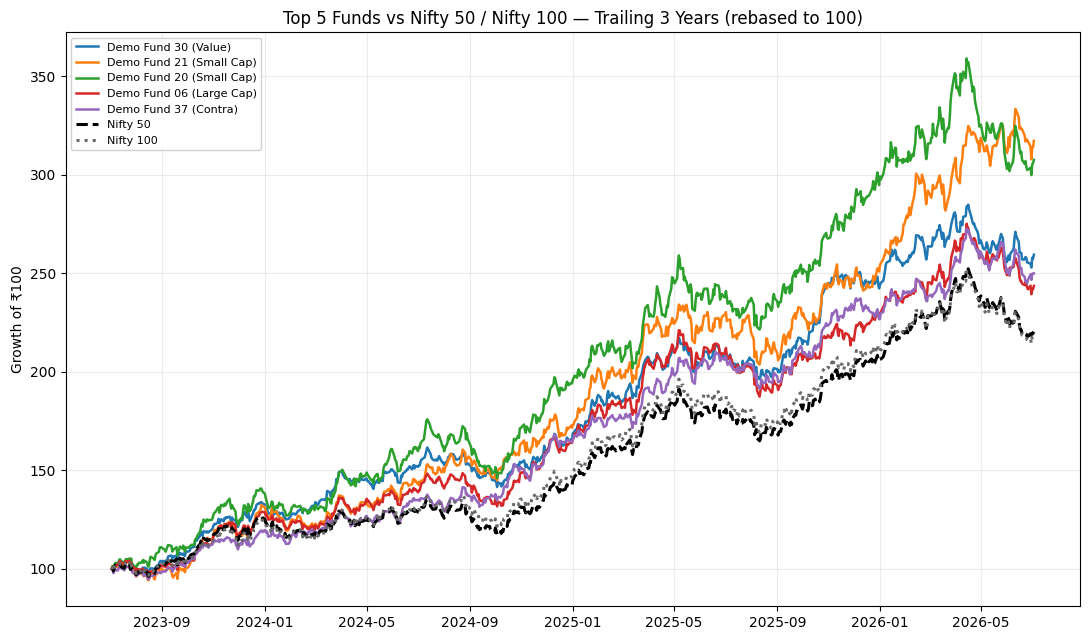

In [12]:
top5 = scorecard.head(TOP_N).index.tolist()

chart_start = asof - pd.DateOffset(years=3)
nav_chart = nav_wide.loc[nav_wide.index >= chart_start, top5]
bench_chart = bench.loc[bench.index >= chart_start]

nav_norm = nav_chart / nav_chart.iloc[0] * 100
bench_norm = bench_chart / bench_chart.iloc[0] * 100

fig, ax = plt.subplots(figsize=(11, 6.5))
for code in top5:
    ax.plot(nav_norm.index, nav_norm[code], label=scheme_names[code], linewidth=1.8)
ax.plot(bench_norm.index, bench_norm['Nifty50'], label='Nifty 50', color='black', linestyle='--', linewidth=2.2)
ax.plot(bench_norm.index, bench_norm['Nifty100'], label='Nifty 100', color='dimgray', linestyle=':', linewidth=2.2)
ax.set_title('Top 5 Funds vs Nifty 50 / Nifty 100 — Trailing 3 Years (rebased to 100)')
ax.set_ylabel('Growth of ₹100')
ax.grid(alpha=0.25)
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150)
plt.show()

In [13]:
fund_ret_chart = nav_chart.pct_change().iloc[1:]
bench_ret_chart = bench_chart.pct_change().iloc[1:]

te_records = []
for code in top5:
    common = fund_ret_chart.index.intersection(bench_ret_chart.index)
    te50 = (fund_ret_chart.loc[common, code] - bench_ret_chart.loc[common, 'Nifty50']).std() * np.sqrt(TRADING_DAYS)
    te100 = (fund_ret_chart.loc[common, code] - bench_ret_chart.loc[common, 'Nifty100']).std() * np.sqrt(TRADING_DAYS)
    te_records.append({'Scheme_Code': code, 'Tracking_Error_vs_Nifty50': te50,
                        'Tracking_Error_vs_Nifty100': te100})

te_df = pd.DataFrame(te_records).set_index('Scheme_Code').join(scheme_names)
te_df.round(4)

,Tracking_Error_vs_Nifty50,Tracking_Error_vs_Nifty100,Scheme_Name
Scheme_Code,,,
DEMO30,0.0622,0.0560,Demo Fund 30 (Value)
DEMO21,0.1038,0.0969,Demo Fund 21 (Small Cap)
DEMO20,0.0907,0.0816,Demo Fund 20 (Small Cap)
DEMO06,0.0614,0.0501,Demo Fund 06 (Large Cap)
DEMO37,0.0836,0.0792,Demo Fund 37 (Contra)


## 10. Summary

**Reminder: this run used synthetic placeholder data** (see the top of this
notebook). Replace `nav_data.csv`, `benchmark_data.csv`, `expense_ratio.csv`
with real files using the same column names, then *Restart & Run All* — no
code changes needed.

In [14]:
print("Deliverables written to this folder:")
for f in ['fund_scorecard.csv', 'alpha_beta.csv', 'benchmark_comparison.png', 'return_distribution.png']:
    print(f" - {f}  ({'OK' if os.path.exists(f) else 'MISSING'})")

print("\nTop 5 by composite scorecard (this demo run):")
scorecard[['Rank', 'Scheme_Name', 'Composite_Score']].head()

Deliverables written to this folder:
 - fund_scorecard.csv  (OK)
 - alpha_beta.csv  (OK)
 - benchmark_comparison.png  (OK)
 - return_distribution.png  (OK)

Top 5 by composite scorecard (this demo run):


,Rank,Scheme_Name,Composite_Score
Scheme_Code,,,
DEMO30,1,Demo Fund 30 (Value),87.6250
DEMO21,2,Demo Fund 21 (Small Cap),84.3125
DEMO20,3,Demo Fund 20 (Small Cap),83.3125
DEMO06,4,Demo Fund 06 (Large Cap),83.0000
DEMO37,5,Demo Fund 37 (Contra),78.2500
